# 05 — Classic Pipeline: Preprocessing & Experiments

End-to-end **classical ML/DL pipeline** for Sysmon-based anomaly detection and ATT&CK attribution.

| Stage | Approach | Training data |
|---|---|---|
| **1. Text preprocessing** | Normalize → redact volatile tokens → word TF-IDF fitted on benign-only | LMD benign |
| **2. Structural features** | Factual path/cmdline properties (depth, entropy, redacted token flags) | — |
| **3. Anomaly detection (event)** | Isolation Forest / Autoencoder on per-event feature vector | LMD benign-only |
| **4. Anomaly detection (sequence)** | GRU/Transformer autoencoder on session-windowed sequences | LMD benign-only |
| **5. Technique attribution** | Supervised multi-class classifier on ground-truth T-codes | OTRF Atomic + Splunk |

**Core principle:** no hardcoded lists, no rule-based matching — all signal is learned from the data distribution.

## Imports and setup

In [1]:
import sys
sys.path.insert(0, r'h:\Challenge-3-4\cyber-anomaly-detection')

import re
import math
import logging
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

import mlflow
mlflow.set_tracking_uri('file:./mlruns')

logging.basicConfig(level=logging.WARNING)
sns.set_theme(style='whitegrid')
%matplotlib inline

TEXT_COLS = ['image', 'command_line', 'parent_image', 'parent_cmdline', 'target_object']
print('Setup complete.')

Setup complete.


## 1. Data Assembly

Three data pools are assembled:

| Pool | Source | Label | Role |
|---|---|---|---|
| **Benign train** | LMD-2023 `label=0` | 0 | Fit TF-IDF; train anomaly detectors |
| **Malicious** | OTRF Atomic + Compound + Splunk techniques | 1 | Evaluate anomaly detection; train technique classifier |
| **Mixed test** | LMD-2023 `label>0` | 1/2 | Anomaly detection evaluation |

APT29 (label=-1, no ground truth) is excluded entirely.

In [2]:
from data.ingest.lmd2023 import iter_chunks as lmd_iter
from data.ingest.otrf import iter_compound, iter_atomic
from data.ingest.splunk import iter_techniques as splunk_iter

# ── LMD benign (anomaly detector training set) ──────────────────────────────
print('Loading LMD benign...')
benign_chunks = [c for c in lmd_iter(variant='2.3M', benign_only=True)]
df_benign = pd.concat(benign_chunks, ignore_index=True)
print(f'  LMD benign     : {len(df_benign):,} events')

# ── LMD malicious (test set labels 1 = EoRS, 2 = EoHT) ─────────────────────
print('Loading LMD malicious...')
mal_lmd = [c[c['label'] > 0] for c in lmd_iter(variant='2.3M') if (c['label'] > 0).any()]
df_lmd_mal = pd.concat(mal_lmd, ignore_index=True)
print(f'  LMD malicious  : {len(df_lmd_mal):,} events  dist: {df_lmd_mal["label"].value_counts().to_dict()}')

# ── OTRF Atomic (labelled, T-codes) ─────────────────────────────────────────
print('Loading OTRF Atomic...')
atomic_chunks = [c[c['label'] == 1] for c in iter_atomic()]
df_atomic = pd.concat(atomic_chunks, ignore_index=True) if atomic_chunks else pd.DataFrame()
print(f'  OTRF Atomic    : {len(df_atomic):,} events  T-codes: {df_atomic["attck_technique"].nunique()}')

# ── OTRF Compound (LSASS campaigns + Log4Shell) ──────────────────────────────
print('Loading OTRF Compound...')
compound_chunks = list(iter_compound())
df_compound = pd.concat(compound_chunks, ignore_index=True) if compound_chunks else pd.DataFrame()
print(f'  OTRF Compound  : {len(df_compound):,} events  T-codes: {df_compound["attck_technique"].nunique() if not df_compound.empty else 0}')

# ── Splunk techniques (all label=1, 293 T-codes) ─────────────────────────────
print('Loading Splunk techniques...')
splunk_chunks = list(splunk_iter())
df_splunk = pd.concat(splunk_chunks, ignore_index=True) if splunk_chunks else pd.DataFrame()
print(f'  Splunk         : {len(df_splunk):,} events  T-codes: {df_splunk["attck_technique"].nunique()}')

# ── Combined labelled malicious corpus ───────────────────────────────────────
df_malicious = pd.concat([df_lmd_mal, df_atomic, df_compound, df_splunk], ignore_index=True)
print(f'\nTotal benign    : {len(df_benign):,}')
print(f'Total malicious : {len(df_malicious):,}')
print(f'Grand total     : {len(df_benign) + len(df_malicious):,}')

Loading LMD benign...
  LMD benign     : 1,632,903 events
Loading LMD malicious...
  LMD malicious  : 511,105 events  dist: {1: 375239, 2: 135866}
Loading OTRF Atomic...
  OTRF Atomic    : 543,077 events  T-codes: 53
Loading OTRF Compound...
  OTRF Compound  : 328,019 events  T-codes: 2
Loading Splunk techniques...
  Splunk         : 2,065,466 events  T-codes: 177

Total benign    : 1,632,903
Total malicious : 3,447,667
Grand total     : 5,080,570


### Dataset Summary

In [3]:
# Dataset summary
labelled_mal = pd.concat([df_atomic, df_compound, df_splunk], ignore_index=True)

summary = pd.DataFrame([
    {'source': 'LMD-2023 (benign)',     'events': len(df_benign),    'label': '0',    'T-codes': 0},
    {'source': 'LMD-2023 (malicious)',  'events': len(df_lmd_mal),   'label': '1,2',  'T-codes': 0},
    {'source': 'OTRF Atomic',           'events': len(df_atomic),    'label': '1',    'T-codes': df_atomic['attck_technique'].nunique()},
    {'source': 'OTRF Compound',         'events': len(df_compound),  'label': '1',    'T-codes': df_compound['attck_technique'].nunique() if not df_compound.empty else 0},
    {'source': 'Splunk techniques',     'events': len(df_splunk),    'label': '1',    'T-codes': df_splunk['attck_technique'].nunique()},
])
summary['events'] = summary['events'].map('{:,}'.format)
print(summary.to_string(index=False))

print(f'\nUnique T-codes (labelled malicious): {labelled_mal["attck_technique"].nunique()}')
print('\nTop 10 T-codes by event count:')
print(labelled_mal['attck_technique'].value_counts().head(10).to_string())

              source    events label  T-codes
   LMD-2023 (benign) 1,632,903     0        0
LMD-2023 (malicious)   511,105   1,2        0
         OTRF Atomic   543,077     1       53
       OTRF Compound   328,019     1        2
   Splunk techniques 2,065,466     1      177

Unique T-codes (labelled malicious): 189

Top 10 T-codes by event count:
attck_technique
T1003.001    342107
T1053.005    250238
T1566.001    245015
T1562.002    174948
T1548        152296
T1055        118704
T1547.012    116396
T1059.001    114431
T1021.003     87565
T1546.003     77063


## 2. Text Field Analysis

Sysmon text fields are **structured strings, not natural language**. Each has a specific grammar:

| Field | Structure | Key structural properties |
|---|---|---|
| `image` / `parent_image` | Windows path | Delimiter: `\`, components: drive → dirs → basename.ext |
| `command_line` / `parent_cmdline` | Executable + flags + arguments | Delimiter: space/pipe/semicolon; may contain encoded blobs |
| `target_object` | Registry or file path | Registry hives (HKLM/HKCU), key hierarchy |

Before choosing any representation, we inspect what these fields actually look like in benign vs malicious data — length distributions, fill rates, and raw examples. This drives the normalization strategy.

In [4]:
# Raw field samples: benign vs malicious side by side
print('=== Field fill rates (non-null & non-empty %) ===')
for col in TEXT_COLS:
    b_fill = df_benign[col].replace('', pd.NA).notna().mean() * 100 if col in df_benign.columns else 0.0
    m_fill = df_malicious[col].replace('', pd.NA).notna().mean() * 100 if col in df_malicious.columns else 0.0
    print(f'  {col:22s}  benign={b_fill:5.1f}%  malicious={m_fill:5.1f}%')

print('\n=== Sample command lines — Benign ===')
for cmd in df_benign['command_line'].dropna().sample(5, random_state=1):
    print(f'  {str(cmd)[:120]}')

print('\n=== Sample command lines — Malicious ===')
for cmd in df_malicious['command_line'].dropna().sample(5, random_state=1):
    print(f'  {str(cmd)[:120]}')

print('\n=== Sample image paths — Benign ===')
for img in df_benign['image'].dropna().sample(5, random_state=2):
    print(f'  {img}')

print('\n=== Sample image paths — Malicious ===')
for img in df_malicious['image'].dropna().sample(5, random_state=2):
    print(f'  {img}')

=== Field fill rates (non-null & non-empty %) ===
  image                   benign=100.0%  malicious= 66.8%
  command_line            benign=100.0%  malicious= 16.9%
  parent_image            benign=100.0%  malicious= 16.9%
  parent_cmdline          benign=100.0%  malicious= 16.9%
  target_object           benign=100.0%  malicious= 25.4%

=== Sample command lines — Benign ===
  0
  0
  0
  0
  0

=== Sample command lines — Malicious ===
  
  
  
  
  0

=== Sample image paths — Benign ===
  System
  System
  System
  System
  System

=== Sample image paths — Malicious ===
  0
  C:\Program Files\Amazon\SSM\amazon-ssm-agent.exe
  C:\Program Files\SplunkUniversalForwarder\bin\splunk-winprintmon.exe
  C:\windows\system32\LogonUI.exe
  0


## 3. Preprocessing

Three layers applied in sequence before any model sees the data:

**Layer 1 — Normalization & Redaction** (field-aware)
- Strip drive letters, lowercase, anonymize usernames → reduce spurious variation
- Replace volatile tokens with typed placeholders: `<b64>` (base64 blobs), `<ip>` (IPv4 addresses), `<hex>` (long hex strings)
- The placeholders are themselves features — their *presence* is signal, their *content* is noise

**Layer 2 — Tokenization**
- Paths: split on `\/.` delimiters → space-separated path component tokens
- Command lines: split on whitespace and shell metacharacters
- Registry: normalize hive names (HKEY_LOCAL_MACHINE → hklm), split on `\`

**Layer 3 — Word-level TF-IDF fitted on benign-only**
- One TF-IDF vectorizer per field, fitted **only on LMD benign events**
- IDF scores encode how common each token is in *normal* Windows activity
- Tokens rare in benign traffic automatically carry high weight — no list of "suspicious" tokens is ever written
- Followed by TruncatedSVD (LSA) for dimensionality reduction

### 3.1 Normalization & Tokenization Functions

In [3]:
# ── Path normalization ──────────────────────────────────────────────────────
def normalize_path(p: str) -> str:
    """Lowercase, strip drive letter, anonymize user dirs."""
    if not p or not isinstance(p, str):
        return ''
    p = p.lower().strip()
    p = re.sub(r'^[a-z]:\\', r'\\', p)                                         # C:\ → \
    p = re.sub(r'\\users\\[^\\]+\\', r'\\users\\<user>\\', p)                  # \users\alice\ → \users\<user>\
    p = re.sub(r'\\[0-9a-f]{8}(?:-[0-9a-f]{4}){3}-[0-9a-f]{12}\\', r'\\<guid>\\', p, flags=re.I)
    return p

def tokenize_path(p: str) -> str:
    norm = normalize_path(p)
    tokens = re.split(r'[\\/.]+', norm)
    return ' '.join(t for t in tokens if len(t) > 1)

# ── Command-line normalization ──────────────────────────────────────────────
def normalize_cmdline(cmd: str) -> str:
    """Lowercase and redact volatile payloads with typed placeholders."""
    if not cmd or not isinstance(cmd, str):
        return ''
    cmd = cmd.lower().strip()
    cmd = re.sub(r'[a-z0-9+/]{40,}={0,2}', '<b64>', cmd)            # base64 blobs
    cmd = re.sub(r'\b\d{1,3}(?:\.\d{1,3}){3}\b', '<ip>', cmd)       # IPv4 addresses
    cmd = re.sub(r'\b[0-9a-f]{16,}\b', '<hex>', cmd)                 # long hex strings
    cmd = re.sub(r':\d{2,5}\b', ':<port>', cmd)                      # :<port> patterns
    return cmd

def tokenize_cmdline(cmd: str) -> str:
    norm = normalize_cmdline(cmd)
    tokens = re.split(r'[\s\\|;&^"\'`,()\[\]/]+', norm)
    return ' '.join(t for t in tokens if len(t) > 1)

# ── Registry / file TargetObject ───────────────────────────────────────────
def tokenize_registry(obj: str) -> str:
    if not obj or not isinstance(obj, str):
        return ''
    obj = obj.lower()
    obj = re.sub(r'^hkey_local_machine', 'hklm', obj)
    obj = re.sub(r'^hkey_current_user', 'hkcu', obj)
    obj = re.sub(r'^hkey_users', 'hku', obj)
    obj = re.sub(r's-\d+-\d+-\d+(?:-\d+){1,10}', '<sid>', obj)      # anonymize user SIDs
    tokens = re.split(r'[\\/.]+', obj)
    return ' '.join(t for t in tokens if len(t) > 1)

# ── Dispatcher ─────────────────────────────────────────────────────────────
def tokenize_field(series: pd.Series, col: str) -> pd.Series:
    if col in ('image', 'parent_image', 'image_loaded'):
        return series.fillna('').map(tokenize_path)
    elif col in ('command_line', 'parent_cmdline'):
        return series.fillna('').map(tokenize_cmdline)
    elif col == 'target_object':
        return series.fillna('').map(tokenize_registry)
    return series.fillna('').astype(str)

print('Normalization and tokenization functions defined.')

Normalization and tokenization functions defined.


#### Validate normalization

In [11]:
def _valid(series: pd.Series, min_len: int = 5) -> pd.Series:
    """Filter out null, empty, and sentinel '0' values."""
    return series.dropna().replace('0', pd.NA).dropna().astype(str).pipe(
        lambda s: s[s.str.len() >= min_len]
    )

print('=== PATH normalization ===')
for raw in _valid(df_malicious['image']).sample(5, random_state=10):
    print(f'  RAW : {raw}')
    print(f'  TOK : {tokenize_path(raw)}\n')

print('=== COMMAND-LINE normalization ===')
for raw in _valid(df_malicious['command_line'], min_len=10).sample(5, random_state=10):
    print(f'  RAW : {str(raw)[:120]}')
    print(f'  TOK : {tokenize_cmdline(str(raw))[:120]}\n')

print('=== REGISTRY normalization ===')
reg_vals = _valid(df_malicious['target_object']) if 'target_object' in df_malicious.columns else pd.Series([], dtype=str)
if not reg_vals.empty:
    for raw in reg_vals.sample(min(5, len(reg_vals)), random_state=10):
        print(f'  RAW : {raw}')
        print(f'  TOK : {tokenize_registry(raw)}\n')
else:
    print('  (no valid target_object entries in malicious sample)')

=== PATH normalization ===
  RAW : C:\Windows\System32\wermgr.exe
  TOK : windows system32 wermgr exe

  RAW : C:\Windows\System32\VBoxService.exe
  TOK : windows system32 vboxservice exe

  RAW : C:\Windows\sysmon64.exe
  TOK : windows sysmon64 exe

  RAW : C:\Windows\SystemApps\Microsoft.Windows.Cortana_cw5n1h2txyewy\SearchUI.exe
  TOK : windows systemapps microsoft windows cortana_cw5n1h2txyewy searchui exe

  RAW : C:\windows\system32\lsass.exe
  TOK : windows system32 lsass exe

=== COMMAND-LINE normalization ===
  RAW : C:\Windows\system32\cmd.exe /c ""C:\Program Files\SplunkUniversalForwarder\etc\system\bin\powershell2.cmd" --scheme"
  TOK : c: windows system32 cmd.exe c: program files splunkuniversalforwarder etc system bin powershell2.cmd --scheme

  RAW : C:\Windows\system32\svchost.exe -k LocalService -s W32Time
  TOK : c: windows system32 svchost.exe -k localservice -s w32time

  RAW : C:\Windows\system32\cmd.exe /c ""C:\Program Files\SplunkUniversalForwarder\etc\system\bin

### 3.2 Structural Features

Factual, data-driven features derived from the field structure. No predetermined list of "suspicious" values is used — these are geometric and informational properties of the strings:

| Feature | What it measures |
|---|---|
| `img_depth` / `par_depth` | Directory nesting depth of the executable path |
| `img_in_system` / `par_in_system` | Executable resides in `\windows\system` — the expected location |
| `img_in_user` / `par_in_user` | Executable in user-writable dir (profile/appdata) |
| `img_in_temp` / `par_in_temp` | Executable staged in temp directory |
| `img_entropy` / `par_entropy` | Shannon entropy of the executable basename — high value signals obfuscated names |
| `cmd_len` / `pcmd_len` | Raw command-line character length |
| `cmd_arg_count` | Number of space-separated tokens in the command line |
| `cmd_has_b64` | `<b64>` placeholder present after normalization |
| `cmd_has_ip` | `<ip>` placeholder present — IP literal in command line |
| `cmd_has_hex` | `<hex>` placeholder — long hex string (shellcode / hashes) |
| `tobj_depth` | Registry/file path nesting depth |
| `tobj_is_run` | TargetObject path references a Run/RunOnce key |

In [4]:
def path_entropy(s: str) -> float:
    if not s:
        return 0.0
    counts = Counter(s.lower())
    total = len(s)
    return -sum((c / total) * math.log2(c / total) for c in counts.values())

def extract_structural(df: pd.DataFrame) -> pd.DataFrame:
    feat = pd.DataFrame(index=df.index)

    # ── image / parent_image ──────────────────────────────────────────────
    for prefix, col in [('img', 'image'), ('par', 'parent_image')]:
        raw  = df[col].fillna('').str.lower() if col in df.columns else pd.Series('', index=df.index)
        norm = raw.map(normalize_path)
        base = norm.str.split('\\').str[-1]
        feat[f'{prefix}_depth']      = norm.str.count(r'\\').astype(np.float32)
        feat[f'{prefix}_in_system']  = norm.str.contains(r'\\windows\\system', regex=True).astype(np.float32)
        feat[f'{prefix}_in_user']    = norm.str.contains(r'\\users\\', regex=True).astype(np.float32)
        feat[f'{prefix}_in_temp']    = norm.str.contains(r'\\temp\\|\\tmp\\|\\appdata\\', regex=True).astype(np.float32)
        feat[f'{prefix}_entropy']    = base.map(path_entropy).astype(np.float32)
        feat[f'{prefix}_name_len']   = base.str.len().astype(np.float32)

    # ── command_line / parent_cmdline ─────────────────────────────────────
    for prefix, col in [('cmd', 'command_line'), ('pcmd', 'parent_cmdline')]:
        raw  = df[col].fillna('') if col in df.columns else pd.Series('', index=df.index)
        norm = raw.map(normalize_cmdline)
        feat[f'{prefix}_len']        = raw.str.len().astype(np.float32)
        feat[f'{prefix}_arg_count']  = raw.str.split().str.len().fillna(0).astype(np.float32)
        feat[f'{prefix}_has_b64']    = norm.str.contains('<b64>', regex=False).astype(np.float32)
        feat[f'{prefix}_has_ip']     = norm.str.contains('<ip>',  regex=False).astype(np.float32)
        feat[f'{prefix}_has_hex']    = norm.str.contains('<hex>', regex=False).astype(np.float32)

    # ── target_object ──────────────────────────────────────────────────────
    if 'target_object' in df.columns:
        tobj = df['target_object'].fillna('').str.lower()
        feat['tobj_depth']   = tobj.str.count(r'\\').astype(np.float32)
        feat['tobj_is_hklm'] = tobj.str.startswith('hklm').astype(np.float32)
        feat['tobj_is_hkcu'] = tobj.str.startswith('hkcu').astype(np.float32)
        feat['tobj_is_run']  = tobj.str.contains(r'\\run\\|\\run$|\\runonce', regex=True).astype(np.float32)

    # ── dest_port ──────────────────────────────────────────────────────────
    if 'dest_port' in df.columns:
        feat['dest_port'] = pd.to_numeric(df['dest_port'], errors='coerce').fillna(-1).astype(np.float32)

    return feat.fillna(0.0)

# Validate on samples
sample_b = df_benign.sample(5_000, random_state=0)
sample_m = df_malicious.sample(5_000, random_state=0)
feat_b = extract_structural(sample_b)
feat_m = extract_structural(sample_m)
print(f'Structural feature dim : {feat_b.shape[1]}')
print(f'Features               : {list(feat_b.columns)}')

Structural feature dim : 27
Features               : ['img_depth', 'img_in_system', 'img_in_user', 'img_in_temp', 'img_entropy', 'img_name_len', 'par_depth', 'par_in_system', 'par_in_user', 'par_in_temp', 'par_entropy', 'par_name_len', 'cmd_len', 'cmd_arg_count', 'cmd_has_b64', 'cmd_has_ip', 'cmd_has_hex', 'pcmd_len', 'pcmd_arg_count', 'pcmd_has_b64', 'pcmd_has_ip', 'pcmd_has_hex', 'tobj_depth', 'tobj_is_hklm', 'tobj_is_hkcu', 'tobj_is_run', 'dest_port']


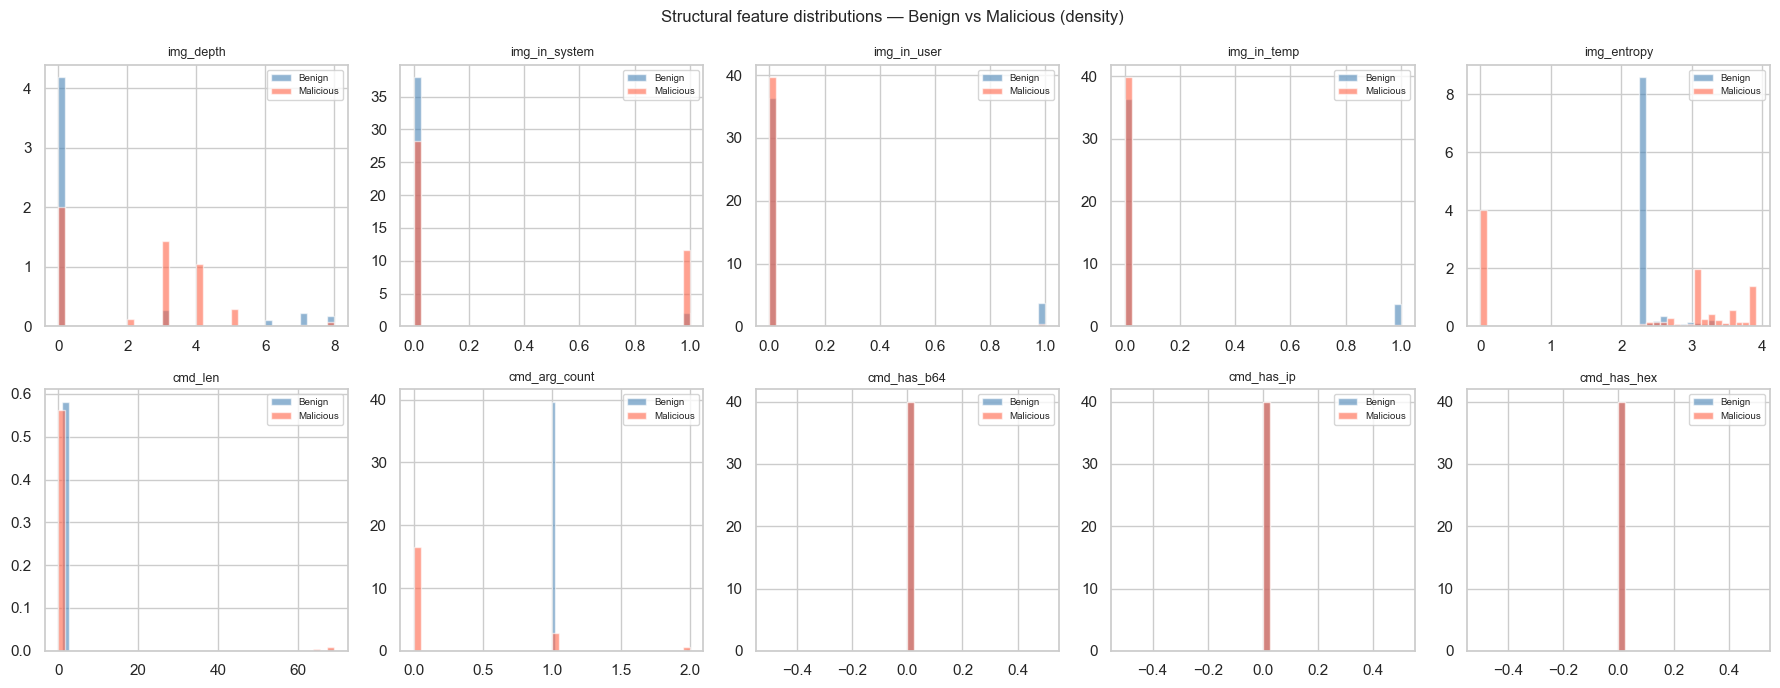

In [13]:
# Structural feature distributions: benign vs malicious
feat_b['_label'] = 'Benign'
feat_m['_label'] = 'Malicious'
combined = pd.concat([feat_b, feat_m], ignore_index=True)

plot_feats = [
    'img_depth', 'img_in_system', 'img_in_user', 'img_in_temp', 'img_entropy',
    'cmd_len', 'cmd_arg_count', 'cmd_has_b64', 'cmd_has_ip', 'cmd_has_hex',
]
plot_feats = [f for f in plot_feats if f in combined.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, feat in zip(axes.flat, plot_feats):
    for lbl, color in [('Benign', 'steelblue'), ('Malicious', 'tomato')]:
        vals = combined[combined['_label'] == lbl][feat].clip(upper=combined[feat].quantile(0.99))
        ax.hist(vals, bins=40, alpha=0.6, label=lbl, color=color, density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Structural feature distributions — Benign vs Malicious (density)', fontsize=12)
plt.tight_layout()
plt.show()

# Clean up temporary label column
feat_b.drop(columns=['_label'], inplace=True)
feat_m.drop(columns=['_label'], inplace=True)

### 3.3 Strategy A — Word-level TF-IDF + SVD

A separate `TfidfVectorizer` is fitted for each text field using **only the benign LMD events**. This is the key design decision: IDF weights encode how common each token is in *normal* Windows activity — tokens rare in benign traffic automatically carry high weight, so the model discovers unusual patterns without being told which ones to look for.

Hyperparameter selection is split into two principled stages:

**Stage 1 — SVD `n_components` via explained variance**
For each field, the minimum number of SVD components that explains ≥ 90% of the variance in the benign TF-IDF matrix is selected automatically. The elbow curve makes the tradeoff explicit and the choice is directly interpretable: *"we retained enough components to explain 90% of the variance in the benign vocabulary."*

**Stage 2 — TF-IDF hyperparameters (`max_features`, `ngram_max`, `min_df`) via Optuna**

Tunes 3 hyperparameters over up to 60 trials with early stopping (patience=10).

| Sample pool | Size | Purpose |
|---|---|---|
| TF-IDF fit corpus | Full benign (~1.5M events), pre-tokenized once | IDF weights reflect the true benign token distribution |
| SVD fit matrix | 300k rows sampled from the TF-IDF corpus | GPU-friendly dense matrix for principal component estimation (10 GB VRAM at max_features=8192) |
| Eval set | 50k benign + 50k malicious (fixed across all trials) | Consistent silhouette evaluation — same events every trial ensures score differences reflect hyperparameters, not sample variance |
| Silhouette sample | 20k drawn from eval set | Limits the O(n²) pairwise distance computation inside `silhouette_score` |

The objective is **silhouette score** on the text-only feature space — it measures how well the chosen hyperparameters produce a feature space where benign and malicious events are separated, without training any downstream model.

After the study, final pipelines are fitted on the full benign corpus using the best params.

> Note: the Optuna search uses the malicious sample to evaluate separability, but the TF-IDF **fitting itself** only ever sees benign data — the search selects *which hyperparameters* to use, not *what the vocabulary contains*.

See **Section 3.5** for Strategy B (Word2Vec / FastText) and the cross-strategy silhouette comparison.


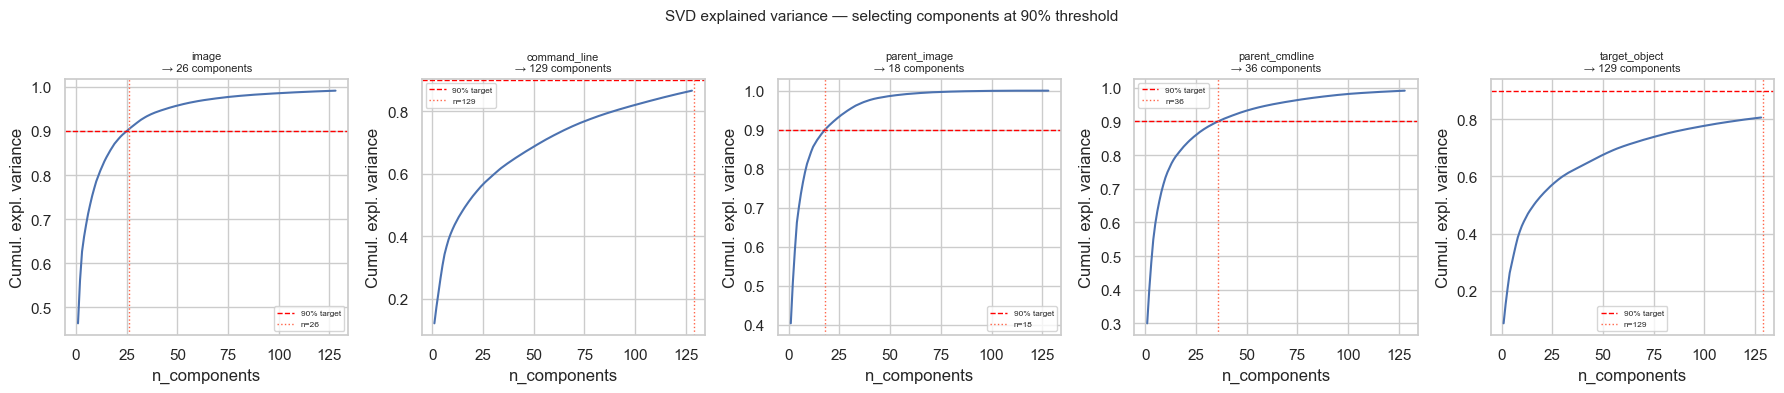


SVD components chosen per field:
  image                   26
  command_line            129
  parent_image            18
  parent_cmdline          36
  target_object           129


In [14]:
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import silhouette_score

# ── Step 1: Automated SVD component selection by explained variance ─────────
# For each field, fit TF-IDF on benign data and find the minimum number of
# SVD components that explains ≥ VARIANCE_TARGET of the TF-IDF matrix variance.
# This is a principled, label-free criterion that is directly interpretable.

VARIANCE_TARGET = 0.90   # retain components explaining 90% of benign-vocab variance
TFIDF_MAX_FEATURES = 4096

svd_components_chosen: dict[str, int] = {}
text_pipelines_full: dict[str, TruncatedSVD] = {}   # full SVD for variance curve

fig, axes = plt.subplots(1, len(TEXT_COLS), figsize=(18, 4))

for ax, col in zip(axes, TEXT_COLS):
    if col not in df_benign.columns:
        svd_components_chosen[col] = 32
        ax.set_title(f'{col}\n(not in data)', fontsize=8)
        continue

    corpus = tokenize_field(df_benign[col], col).tolist()

    tfidf = TfidfVectorizer(
        analyzer='word', ngram_range=(1, 2),
        max_features=TFIDF_MAX_FEATURES, min_df=3, sublinear_tf=True,
    )
    X_tfidf = tfidf.fit_transform(corpus)

    # Fit SVD with enough components to inspect the variance curve
    max_comp = min(128, X_tfidf.shape[1] - 1, X_tfidf.shape[0] - 1)
    svd_full = TruncatedSVD(n_components=max_comp, random_state=42)
    svd_full.fit(X_tfidf)

    cumvar = svd_full.explained_variance_ratio_.cumsum()
    n_chosen = int(np.searchsorted(cumvar, VARIANCE_TARGET)) + 1
    svd_components_chosen[col] = n_chosen
    text_pipelines_full[col] = (tfidf, svd_full)

    ax.plot(range(1, len(cumvar) + 1), cumvar, lw=1.5)
    ax.axhline(VARIANCE_TARGET, color='red', ls='--', lw=1, label=f'{VARIANCE_TARGET:.0%} target')
    ax.axvline(n_chosen, color='tomato', ls=':', lw=1, label=f'n={n_chosen}')
    ax.set_title(f'{col}\n→ {n_chosen} components', fontsize=8)
    ax.set_xlabel('n_components')
    ax.set_ylabel('Cumul. expl. variance')
    ax.legend(fontsize=6)

plt.suptitle(f'SVD explained variance — selecting components at {VARIANCE_TARGET:.0%} threshold', fontsize=11)
plt.tight_layout()
plt.show()

print('\nSVD components chosen per field:')
for col, n in svd_components_chosen.items():
    print(f'  {col:22s}  {n}')

In [31]:
import optuna, json, os, time
import torch
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'SVD device: {DEVICE}')

# ── Configuration ───────────────────────────────────────────────────────────
N_OPTUNA_TRIALS  = 60
EARLY_STOP_PAT   = 10
EVAL_SAMPLE      = 50_000
SVD_FIT_ROWS     = 300_000   # upper bound — actual rows capped by RAM budget below
# Maximum RAM (bytes) to allocate for the dense SVD matrix per field.
# float32 → 4 bytes/element. At max_features=8192:
#   6 GB / (8192 × 4) ≈ 183k rows  (well within SVD_FIT_ROWS)
# At max_features=1024:
#   6 GB / (1024 × 4) ≈ 1.5M rows  (capped to SVD_FIT_ROWS=300k)
SVD_RAM_BUDGET   = int(6e9)
BEST_PARAMS_PATH = Path('optuna_best_params.json')

_svd_rng = np.random.default_rng(42)

# ── Pre-tokenize full benign corpus once ────────────────────────────────────
print(f'Pre-tokenizing full benign corpus ({len(df_benign):,} events)...')
_fit_corpus: dict[str, list[str]] = {
    col: tokenize_field(df_benign[col], col).tolist()
    for col in TEXT_COLS if col in df_benign.columns
}
print('Pre-tokenization done.')

# Fixed evaluation subsample
_eval_b  = df_benign.sample(EVAL_SAMPLE, random_state=99)
_eval_m  = df_malicious.sample(EVAL_SAMPLE, random_state=99)
_eval_df = pd.concat([_eval_b, _eval_m], ignore_index=True)
_eval_y  = np.array([0] * EVAL_SAMPLE + [1] * EVAL_SAMPLE)

def _build_text_features_trial(max_features, ngram_max, min_df, n_components, col):
    """
    TF-IDF fitted on full benign corpus (correct IDF weights).
    SVD fitted on GPU; row count capped to SVD_RAM_BUDGET so the intermediate
    dense float32 matrix never exceeds that RAM allocation.
    """
    tfidf = TfidfVectorizer(
        analyzer='word', ngram_range=(1, ngram_max),
        max_features=max_features, min_df=min_df, sublinear_tf=True,
    )
    tfidf.fit(_fit_corpus[col])

    # Dynamically cap rows: dense matrix = rows × vocab × 4 bytes (float32)
    vocab_size   = len(tfidf.vocabulary_)
    max_rows_ram = SVD_RAM_BUDGET // (vocab_size * 4)
    n_svd_rows   = min(SVD_FIT_ROWS, max_rows_ram, len(_fit_corpus[col]))

    idx   = _svd_rng.choice(len(_fit_corpus[col]), size=n_svd_rows, replace=False)
    X_svd = tfidf.transform([_fit_corpus[col][i] for i in idx])
    n_comp = min(n_components, X_svd.shape[1] - 1)

    # float32 conversion before toarray() — halves the RAM vs float64 default
    X_gpu      = torch.tensor(X_svd.astype(np.float32).toarray(), dtype=torch.float32, device=DEVICE)
    _, _, V    = torch.svd_lowrank(X_gpu, q=n_comp, niter=2)
    # V shape: (n_features, n_comp) — right singular vectors, NOT transposed
    del X_gpu
    torch.cuda.empty_cache()

    # Transform eval set: X_eval @ V  →  (n_eval, n_comp)
    eval_corpus  = tokenize_field(
        _eval_df[col] if col in _eval_df.columns else pd.Series('', index=_eval_df.index),
        col
    ).tolist()
    X_eval     = tfidf.transform(eval_corpus).astype(np.float32)
    X_eval_gpu = torch.tensor(X_eval.toarray(), dtype=torch.float32, device=DEVICE)
    result     = (X_eval_gpu @ V).cpu().numpy()
    del X_eval_gpu
    torch.cuda.empty_cache()
    return result

def objective(trial):
    max_features = trial.suggest_categorical('max_features', [1024, 2048, 4096, 8192])
    ngram_max    = trial.suggest_int('ngram_max', 1, 3)
    min_df       = trial.suggest_int('min_df', 2, 10)

    parts = []
    for col in TEXT_COLS:
        if col not in _eval_df.columns or col not in _fit_corpus:
            continue
        n_comp = svd_components_chosen.get(col, 32)
        parts.append(_build_text_features_trial(max_features, ngram_max, min_df, n_comp, col))

    if not parts:
        return -1.0

    X = np.hstack(parts).astype(np.float32)
    return float(silhouette_score(X, _eval_y, sample_size=20_000, random_state=42))

# ── Callbacks ───────────────────────────────────────────────────────────────
class _EarlyStopping:
    def __init__(self, patience: int, min_delta: float = 1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self._best     = -np.inf
        self._stale    = 0

    def __call__(self, study: optuna.Study, trial: optuna.trial.FrozenTrial):
        if study.best_value > self._best + self.min_delta:
            self._best  = study.best_value
            self._stale = 0
        else:
            self._stale += 1
        if self._stale >= self.patience:
            print(f'\nEarly stop at trial {trial.number} '
                  f'— no improvement in {self.patience} consecutive trials.')
            study.stop()

def _atomic_save(study: optuna.Study, trial: optuna.trial.FrozenTrial):
    if trial.number != study.best_trial.number:
        return
    payload = {
        'params':    study.best_params,
        'value':     study.best_value,
        'trial':     trial.number,
        'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
    }
    tmp = BEST_PARAMS_PATH.with_suffix('.tmp')
    tmp.write_text(json.dumps(payload, indent=2))
    os.replace(tmp, BEST_PARAMS_PATH)
    print(f'  Trial {trial.number}: silhouette={study.best_value:.4f} → saved')

# ── Run study ───────────────────────────────────────────────────────────────
study = optuna.create_study(direction='maximize', study_name='tfidf_hparam_search_v2')
study.optimize(
    objective,
    n_trials=N_OPTUNA_TRIALS,
    callbacks=[_EarlyStopping(patience=EARLY_STOP_PAT), _atomic_save],
    show_progress_bar=True,
)

best = study.best_params
print(f'\nBest params (silhouette={study.best_value:.4f}) after {len(study.trials)} trials:')
for k, v in best.items():
    print(f'  {k:15s}: {v}')

# ── Fit final pipelines on full benign corpus with best params ───────────────
text_pipelines: dict[str, SkPipeline] = {}
for col in TEXT_COLS:
    if col not in df_benign.columns:
        continue
    n_comp = svd_components_chosen.get(col, 32)
    corpus = _fit_corpus.get(col) or tokenize_field(df_benign[col], col).tolist()
    pipe = SkPipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='word', ngram_range=(1, best['ngram_max']),
            max_features=best['max_features'], min_df=best['min_df'], sublinear_tf=True,
        )),
        ('svd', TruncatedSVD(n_components=n_comp, random_state=42)),
    ])
    pipe.fit(corpus)
    text_pipelines[col] = pipe
    print(f'  {col:22s}  vocab={len(pipe.named_steps["tfidf"].vocabulary_):,}  SVD={n_comp}d')

SVD device: cuda
Pre-tokenizing full benign corpus (1,632,903 events)...
Pre-tokenization done.


  0%|          | 0/60 [00:00<?, ?it/s]

  Trial 0: silhouette=0.5821 → saved
  Trial 1: silhouette=0.5989 → saved
  Trial 11: silhouette=0.6004 → saved
  Trial 17: silhouette=0.6055 → saved
  Trial 19: silhouette=0.6064 → saved
  Trial 20: silhouette=0.6095 → saved
  Trial 22: silhouette=0.6098 → saved

Early stop at trial 32 — no improvement in 10 consecutive trials.

Best params (silhouette=0.6098) after 33 trials:
  max_features   : 4096
  ngram_max      : 3
  min_df         : 2
  image                   vocab=2,616  SVD=26d
  command_line            vocab=4,096  SVD=129d
  parent_image            vocab=1,049  SVD=18d
  parent_cmdline          vocab=2,351  SVD=36d
  target_object           vocab=4,096  SVD=129d


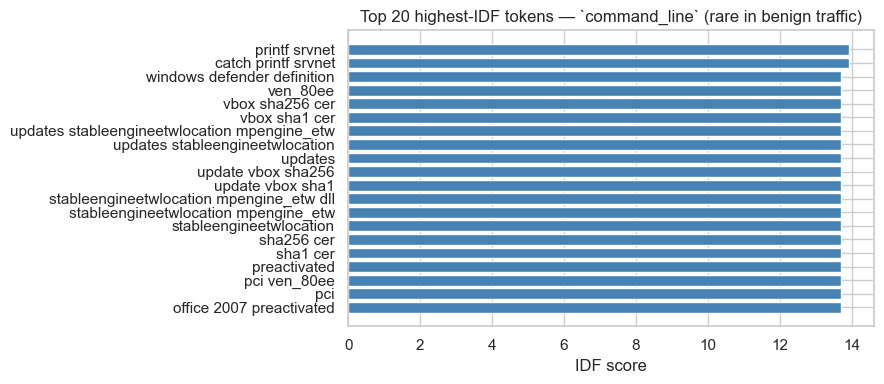

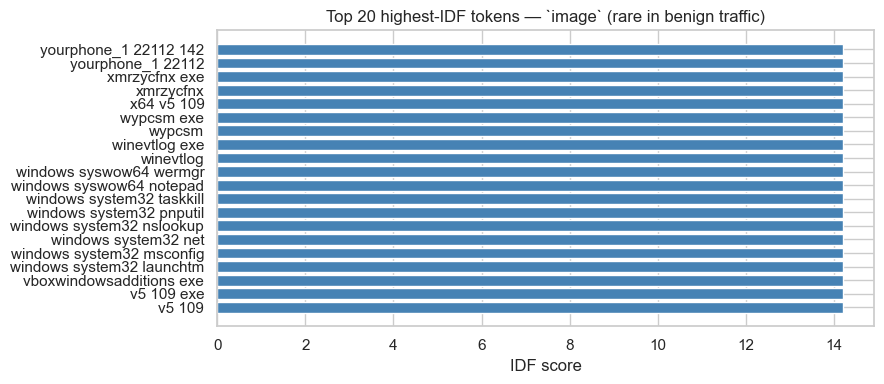

In [43]:
# IDF inspection — what tokens does the benign vocabulary weight highly?
# High IDF = rare in benign traffic = strong anomaly signal if seen at inference
for col in ['command_line', 'image']:
    if col not in text_pipelines:
        continue
    tfidf = text_pipelines[col].named_steps['tfidf']
    vocab  = tfidf.vocabulary_
    idf    = tfidf.idf_

    # Reverse vocabulary: idx → token
    idx_to_token = {v: k for k, v in vocab.items()}
    top_idf = sorted(zip(idf, range(len(idf))), reverse=True)[:20]
    tokens  = [idx_to_token[i] for _, i in top_idf]
    scores  = [s for s, _ in top_idf]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(tokens[::-1], scores[::-1], color='steelblue')
    ax.set_title(f'Top 20 highest-IDF tokens — `{col}` (rare in benign traffic)')
    ax.set_xlabel('IDF score')
    plt.tight_layout()
    plt.show()

### 3.4 Strategy A — Full Feature Matrix Assembly

The final per-event feature vector concatenates three blocks, all fitted on benign-only data:

```
[categorical OrdinalEncoded] + [structural RobustScaled] + [TF-IDF SVD per field × 5]
→ QuantileTransformer(output_distribution='normal')
```

The categorical encoder (`OrdinalEncoder`) and structural scaler (`RobustScaler`) are fitted on benign events, so encoding and scaling reflect the normal operating range. The final `QuantileTransformer` maps each feature's marginal distribution to a standard normal — this handles the near-zero IQR features (e.g. `cmd_len` is 0 for most non-ProcessCreate events) that `RobustScaler` cannot correct.

**Output:** float32 matrix of shape `(n_events, 371)` — 6 categorical + 27 structural + 338 TF-IDF SVD dims.


In [33]:
import psutil
from config import CATEGORICAL_COLS
from sklearn.preprocessing import QuantileTransformer

CAT_COLS = [c for c in CATEGORICAL_COLS if c in df_benign.columns]

_ram_gb = psutil.virtual_memory().total / 1e9
print(f'System RAM : {_ram_gb:.0f} GB')
print(f'Benign events    : {len(df_benign):,}')
print(f'Malicious events : {len(df_malicious):,}')
# Memory forecast at 371 dims float32:
#   X_b     : 1.6M × 371 × 4 ≈  2.4 GB
#   X_m     : 3.4M × 371 × 4 ≈  5.1 GB
#   combined: 5.0M × 371 × 4 ≈  7.5 GB

# ── Fit categorical encoder on benign-only ─────────────────────────────────
cat_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32)
cat_enc.fit(df_benign[CAT_COLS].fillna('__UNK__').astype(str))

# ── Fit structural scaler on full benign corpus ────────────────────────────
print(f'\nFitting structural scaler on {len(df_benign):,} benign events...')
_struct_full = extract_structural(df_benign)
struct_scaler = RobustScaler()
struct_scaler.fit(_struct_full.values)
_n_struct = _struct_full.shape[1]
del _struct_full
print(f'Structural dim : {_n_struct}')

def _raw_feature_matrix(df: pd.DataFrame) -> np.ndarray:
    """Assemble unscaled feature matrix (categorical + structural + text)."""
    parts = []
    if CAT_COLS:
        parts.append(cat_enc.transform(df[CAT_COLS].fillna('__UNK__').astype(str)))
    parts.append(struct_scaler.transform(extract_structural(df).values).astype(np.float32))
    for col, pipe in text_pipelines.items():
        corpus = tokenize_field(
            df[col] if col in df.columns else pd.Series('', index=df.index), col
        ).tolist()
        parts.append(pipe.transform(corpus).astype(np.float32))
    return np.hstack(parts).astype(np.float32)

# ── Compute full benign raw matrix once ────────────────────────────────────
# Reused for: (1) QuantileTransformer fitting, (2) X_b — avoids a second 1.6M pass.
print(f'\nComputing raw feature matrix for all {len(df_benign):,} benign events...')
_X_b_raw = _raw_feature_matrix(df_benign)
print(f'Raw benign matrix : {_X_b_raw.shape}  {_X_b_raw.nbytes / 1e9:.2f} GB')

# ── Fit QuantileTransformer on full benign distribution ─────────────────────
# Fitted on the complete benign population — no sampling needed since the matrix
# is already in memory. 10k quantile bins → accurate CDF approximation.
print('Fitting QuantileTransformer...')
final_scaler = QuantileTransformer(
    n_quantiles=10_000,
    output_distribution='normal',
    random_state=42,
)
final_scaler.fit(_X_b_raw)
print('Done.')

def build_feature_matrix(df: pd.DataFrame) -> np.ndarray:
    """Transform a canonical DataFrame into a scaled float32 feature matrix."""
    return final_scaler.transform(_raw_feature_matrix(df)).astype(np.float32)

# ── Build full benign matrix (reuse raw to avoid second 1.6M pass) ──────────
print(f'\nScaling benign matrix...')
X_b = final_scaler.transform(_X_b_raw).astype(np.float32)
del _X_b_raw
print(f'X_b : {X_b.shape}  {X_b.nbytes / 1e9:.2f} GB')

# ── Build full malicious matrix ─────────────────────────────────────────────
print(f'Computing feature matrix for all {len(df_malicious):,} malicious events...')
X_m = build_feature_matrix(df_malicious)
print(f'X_m : {X_m.shape}  {X_m.nbytes / 1e9:.2f} GB')

# ── Combined matrix ─────────────────────────────────────────────────────────
X_combined = np.vstack([X_b, X_m])
y_combined  = np.concatenate([
    np.zeros(len(X_b), dtype=np.int8),
    np.ones(len(X_m), dtype=np.int8),
])
print(f'X_combined : {X_combined.shape}  {X_combined.nbytes / 1e9:.2f} GB')

# ── Precomputed balanced subsets for visualization ──────────────────────────
# Indexed from full matrices (no re-processing) — numpy fancy indexing only.
# Three sizes to show how separation clarity scales with sample count.
# PCA and UMAP can use all sizes. t-SNE is O(n²) and starts taking hours beyond
# ~100k events total; capped at 50k/class so it stays in the minutes range.
VIZ_SIZES    = [50_000, 200_000, 500_000]   # per class for PCA / UMAP
TSNE_CAP     = 50_000                        # t-SNE cap per class (O(n²) on CPU)
_rng = np.random.default_rng(0)
viz_subsets: dict[int, dict] = {}
for n in sorted(set(VIZ_SIZES + [TSNE_CAP])):
    ib = _rng.choice(len(X_b), size=n, replace=False)
    im = _rng.choice(len(X_m), size=n, replace=False)
    X  = np.vstack([X_b[ib], X_m[im]])
    y  = np.array([0] * n + [1] * n, dtype=np.int8)
    viz_subsets[n] = {'X': X, 'y': y}
    print(f'  viz n={n:>7,}/class  shape={X.shape}  {X.nbytes / 1e6:.0f} MB')

# ── Feature dimension breakdown ─────────────────────────────────────────────
_n_cat  = len(CAT_COLS)
_n_text = X_b.shape[1] - _n_cat - _n_struct
print(f'\nFeature blocks — total {X_b.shape[1]} dims:')
print(f'  categorical : {_n_cat}')
print(f'  structural  : {_n_struct}')
print(f'  text SVD    : {_n_text}')

System RAM : 34 GB
Benign events    : 1,632,903
Malicious events : 3,447,667

Fitting structural scaler on 1,632,903 benign events...
Structural dim : 27

Computing raw feature matrix for all 1,632,903 benign events...
Raw benign matrix : (1632903, 371)  2.42 GB
Fitting QuantileTransformer...
Done.

Scaling benign matrix...
X_b : (1632903, 371)  2.42 GB
Computing feature matrix for all 3,447,667 malicious events...
X_m : (3447667, 371)  5.12 GB
X_combined : (5080570, 371)  7.54 GB
  viz n= 50,000/class  shape=(100000, 371)  148 MB
  viz n=200,000/class  shape=(400000, 371)  594 MB
  viz n=500,000/class  shape=(1000000, 371)  1484 MB

Feature blocks — total 371 dims:
  categorical : 6
  structural  : 27
  text SVD    : 338


#### Feature matrix sanity check 

In [38]:
# ── Feature matrix sanity check — full matrices ────────────────────────────
print(f'X_b        : {X_b.shape}  {X_b.nbytes / 1e9:.2f} GB')
print(f'X_m        : {X_m.shape}  {X_m.nbytes / 1e9:.2f} GB')
print(f'X_combined : {X_combined.shape}  {X_combined.nbytes / 1e9:.2f} GB')
print(f'dtype      : {X_b.dtype}')
print(f'NaN count  : {np.isnan(X_combined).sum()}')
print(f'Inf count  : {np.isinf(X_combined).sum()}')

# Compute stats on a 200k balanced subsample — std on 5M takes ~30s on CPU
_ns = 200_000
_ib = np.random.default_rng(1).choice(len(X_b), _ns, replace=False)
_im = np.random.default_rng(1).choice(len(X_m), _ns, replace=False)
_Xs = np.vstack([X_b[_ib], X_m[_im]])

stds = _Xs.std(axis=0)
print(f'\nFeature std stats (computed on 2×{_ns:,} balanced subsample):')
print(f'  zero-variance : {(stds == 0).sum()} / {len(stds)}')
print(f'  min std       : {stds.min():.6f}')
print(f'  max std       : {stds.max():.6f}')
print(f'  median std    : {np.median(stds):.6f}')

print(f'\nPer-block breakdown:')
for name, sl in [('categorical', slice(0, _n_cat)),
                 ('structural',  slice(_n_cat, _n_cat + _n_struct)),
                 ('text',        slice(_n_cat + _n_struct, None))]:
    bs = stds[sl]
    print(f'  {name:12s}  zero-var={int((bs == 0).sum()):3d}'
          f'  median_std={np.median(bs):.4f}'
          f'  max_std={bs.max():.4f}')

X_b        : (1632903, 371)  2.42 GB
X_m        : (3447667, 371)  5.12 GB
X_combined : (5080570, 371)  7.54 GB
dtype      : float32
NaN count  : 0
Inf count  : 0

Feature std stats (computed on 2×200,000 balanced subsample):
  zero-variance : 0 / 371
  min std       : 0.021003
  max std       : 5.131317
  median std    : 0.512084

Per-block breakdown:
  categorical   zero-var=  0  median_std=2.7660  max_std=4.9155
  structural    zero-var=  0  median_std=1.0222  max_std=3.9505
  text          zero-var=  0  median_std=0.4479  max_std=5.1313


#### Visual Representation

PCA device: cuda


c:\Users\cesar\miniforge3\envs\cyber-anomaly\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\cesar\miniforge3\envs\cyber-anomaly\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\cesar\miniforge3\envs\cyber-anomaly\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


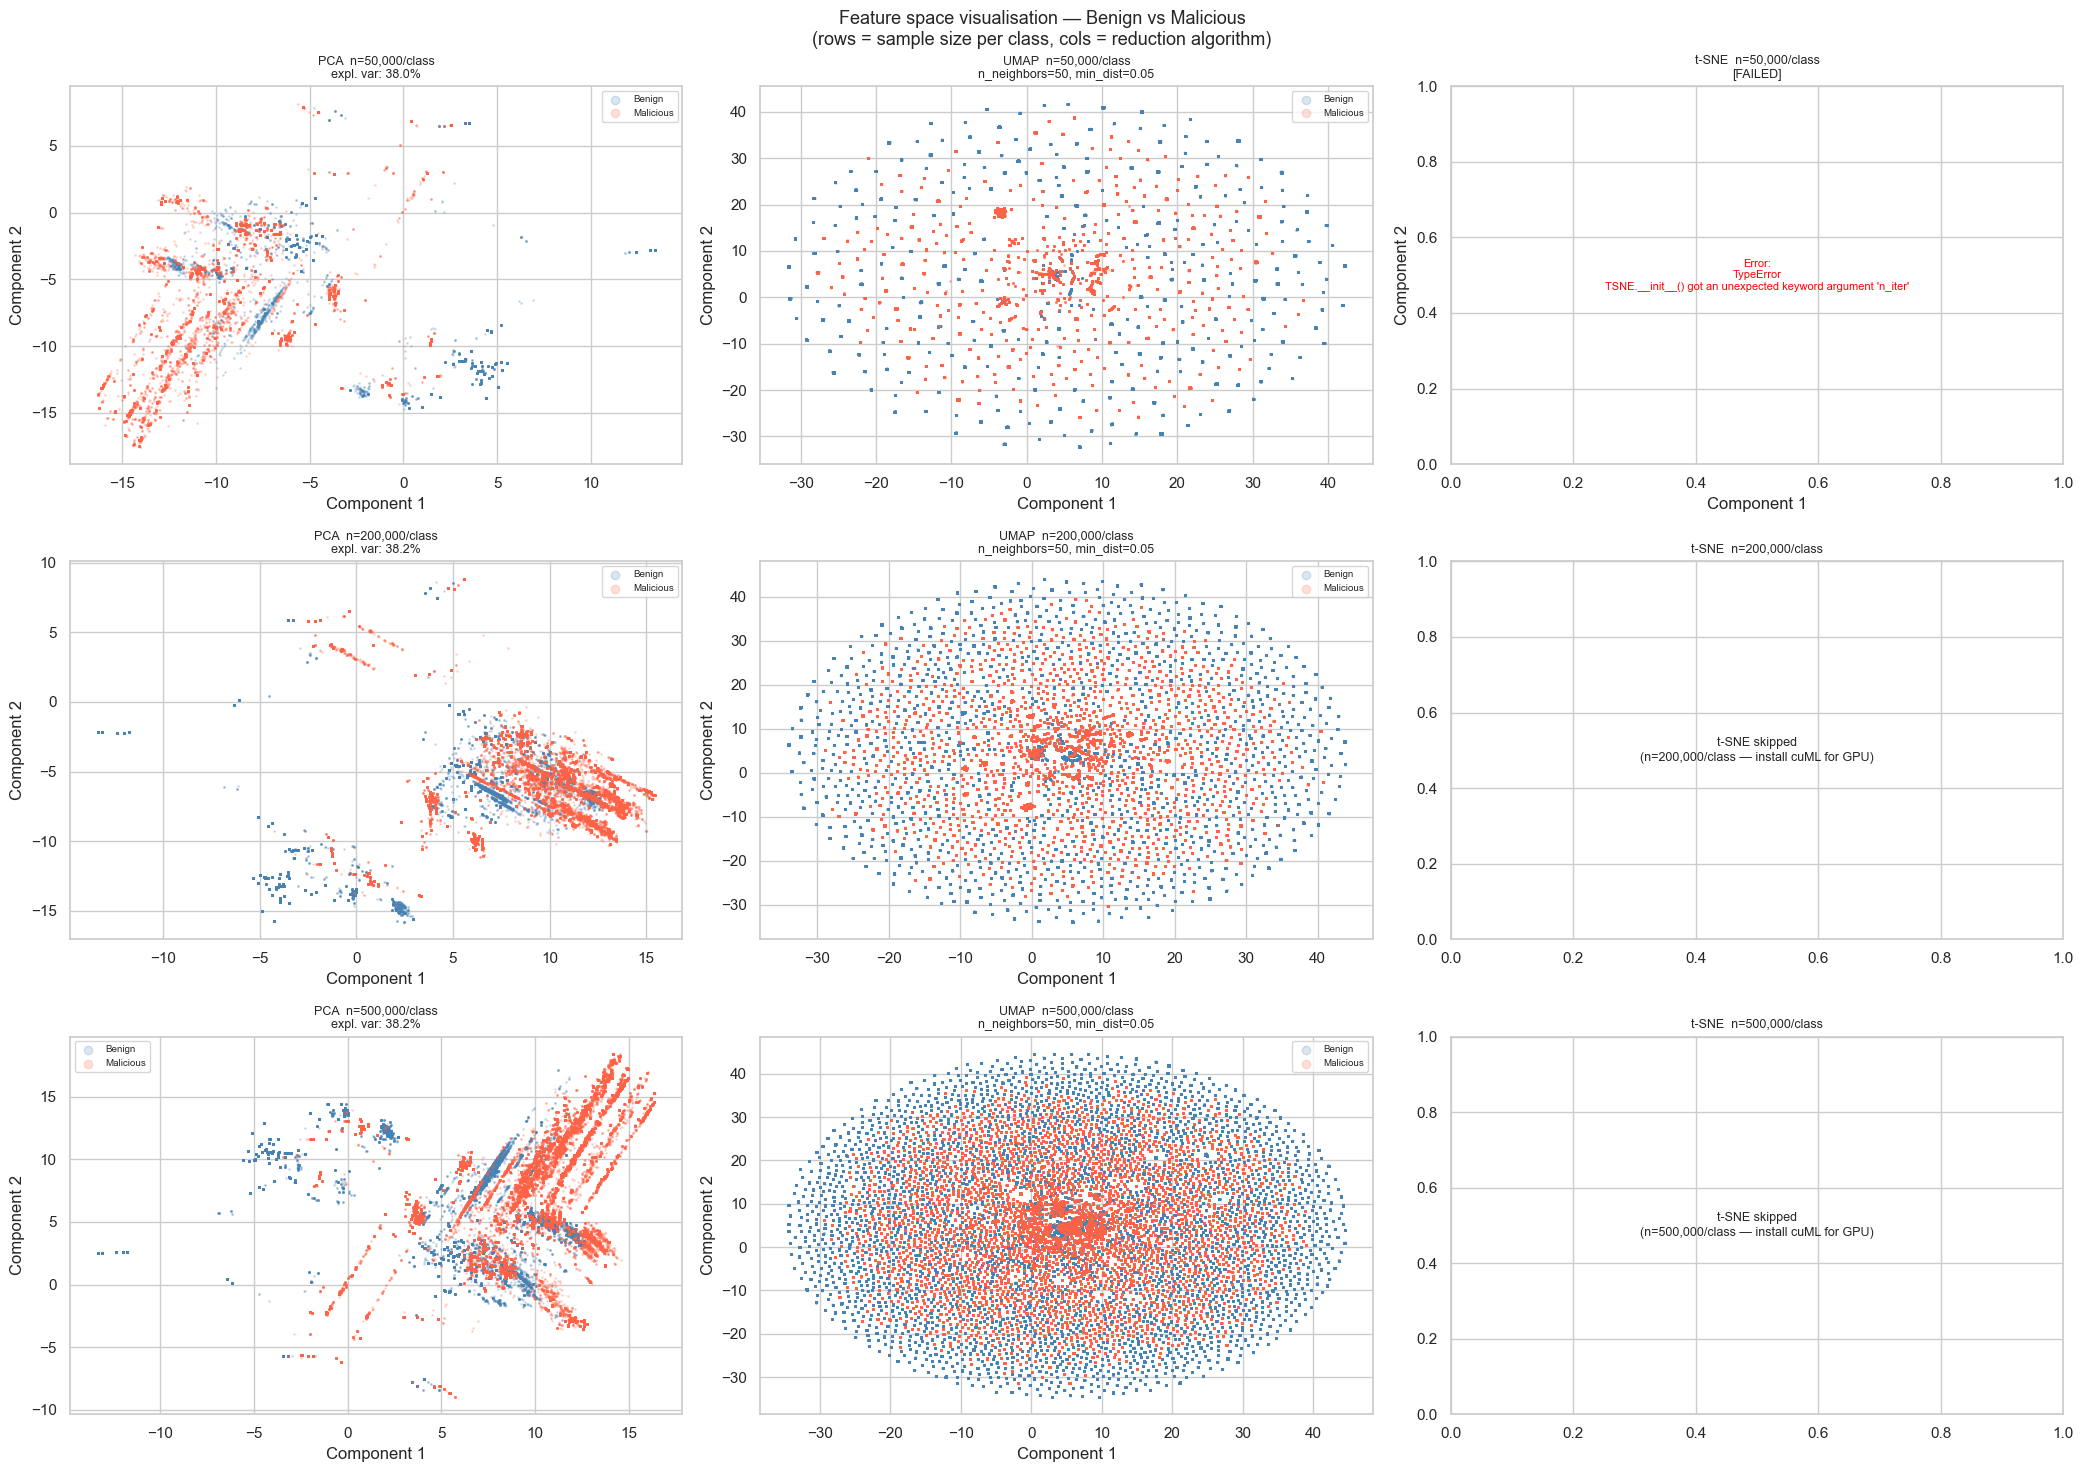

In [39]:
# ── Dimensionality reduction comparison ────────────────────────────────────
# PCA   : torch.pca_lowrank — GPU accelerated
# UMAP  : umap-learn CPU (n_jobs parallelism disabled by random_state)
# t-SNE : sklearn, capped at TSNE_CAP/class on CPU (O(n²) → hours beyond that)

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PCA device: {DEVICE}')

try:
    from umap import UMAP
except ImportError:
    UMAP = None
    print('umap-learn not installed — UMAP panels will be skipped')
from sklearn.manifold import TSNE

ALGORITHMS = ['PCA', 'UMAP', 't-SNE']
_all_sizes = sorted(set(VIZ_SIZES) | {TSNE_CAP})
n_rows     = len(_all_sizes)

fig, axes = plt.subplots(
    n_rows, len(ALGORITHMS),
    figsize=(7 * len(ALGORITHMS), 5 * n_rows),
    squeeze=False,
)

for row, n in enumerate(_all_sizes):
    for col, algo in enumerate(ALGORITHMS):
        ax = axes[row, col]

        # t-SNE: skip sizes above cap on CPU
        if algo == 't-SNE' and n > TSNE_CAP:
            ax.text(0.5, 0.5,
                    f't-SNE skipped\n(n={n:,}/class — install cuML for GPU)',
                    ha='center', va='center', fontsize=9, transform=ax.transAxes)
            ax.set_title(f't-SNE  n={n:,}/class', fontsize=9)
            continue

        X = viz_subsets[n]['X']
        y = viz_subsets[n]['y']

        try:
            if algo == 'PCA':
                X_t     = torch.tensor(X, dtype=torch.float32, device=DEVICE)
                U, S, V = torch.pca_lowrank(X_t, q=2, center=True, niter=4)
                X_2d    = (U * S).cpu().numpy()
                total_var = float(X_t.var(dim=0, correction=1).sum())
                expl_var  = float((S ** 2 / (len(X) - 1)).sum())
                subtitle  = f'expl. var: {expl_var / total_var:.1%}'
                del X_t, U, S, V
                torch.cuda.empty_cache()

            elif algo == 'UMAP':
                if UMAP is None:
                    raise RuntimeError('umap-learn not installed')
                # n_neighbors=50 → denser k-NN graph, avoids disconnected components
                # caused by near-duplicate Sysmon rows (System process, empty fields).
                # init='random' bypasses spectral init which fails on disconnected graphs.
                reducer  = UMAP(n_components=2, n_neighbors=50, min_dist=0.05,
                                random_state=42, init='random')
                X_2d     = reducer.fit_transform(X)
                subtitle = 'n_neighbors=50, min_dist=0.05'

            else:  # t-SNE
                perplexity = min(100, n // 10)
                reducer    = TSNE(n_components=2, perplexity=perplexity,
                                  random_state=42, n_iter=1000, n_jobs=-1)
                X_2d       = reducer.fit_transform(X)
                subtitle   = f'perplexity={perplexity}'

            for lbl, name, color in [(0, 'Benign', 'steelblue'), (1, 'Malicious', 'tomato')]:
                mask = y == lbl
                ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                           s=1, alpha=0.2, label=name, color=color, rasterized=True)
            ax.set_title(f'{algo}  n={n:,}/class\n{subtitle}', fontsize=9)
            ax.legend(markerscale=6, fontsize=7)

        except Exception as e:
            ax.text(0.5, 0.5, f'Error:\n{type(e).__name__}\n{str(e)[:80]}',
                    ha='center', va='center', fontsize=8,
                    transform=ax.transAxes, color='red')
            ax.set_title(f'{algo}  n={n:,}/class\n[FAILED]', fontsize=9)

        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')

plt.suptitle(
    'Feature space visualisation — Benign vs Malicious\n'
    '(rows = sample size per class, cols = reduction algorithm)',
    fontsize=13,
)
plt.tight_layout()
plt.show()

#### Save all preprocessing artifacts

In [ ]:
# ── Checkpoint: save all preprocessing artefacts ───────────────────────────
# Saves everything needed to reconstruct build_feature_matrix() in a fresh
# session or in downstream model-training notebooks — no reprocessing required.
#
# Layout of checkpoints/:
#   shared/         — cat_enc.joblib  struct_scaler.joblib  viz_subsets.pkl
#   tfidf_svd/      — X_b  X_m  X_combined  y_combined  final_scaler  text_pipelines
#   word2vec/       — X_b_w2v  X_m_w2v  final_scaler_w2v  w2v_*.model
#   fasttext/       — X_b_ft   X_m_ft   final_scaler_ft   ft_*.model
#   meta.json       — shared config + stats manifest

import joblib, json, pickle, time
import numpy as np
from pathlib import Path

CKPT_DIR = Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)
(CKPT_DIR / 'shared').mkdir(exist_ok=True)
(CKPT_DIR / 'tfidf_svd').mkdir(exist_ok=True)

# ── Feature matrices ────────────────────────────────────────────────────────
print('Saving feature matrices...')
for name, arr in [('X_b', X_b), ('X_m', X_m),
                  ('X_combined', X_combined), ('y_combined', y_combined)]:
    np.save(CKPT_DIR / 'tfidf_svd' / f'{name}.npy', arr)
    print(f'  {name:12s}  {arr.shape}  {arr.nbytes / 1e9:.2f} GB')

# ── Visualization subsets ───────────────────────────────────────────────────
print('Saving viz subsets...')
with open(CKPT_DIR / 'shared' / 'viz_subsets.pkl', 'wb') as f:
    pickle.dump(viz_subsets, f)

# ── Fitted sklearn objects ──────────────────────────────────────────────────
print('Saving fitted objects...')
joblib.dump(final_scaler,   CKPT_DIR / 'tfidf_svd' / 'final_scaler.joblib')
joblib.dump(cat_enc,        CKPT_DIR / 'shared'    / 'cat_enc.joblib')
joblib.dump(struct_scaler,  CKPT_DIR / 'shared'    / 'struct_scaler.joblib')
joblib.dump(text_pipelines, CKPT_DIR / 'tfidf_svd' / 'text_pipelines.joblib')

# ── Metadata manifest ───────────────────────────────────────────────────────
_optuna_path = Path('optuna_best_params.json')
_optuna_best = json.loads(_optuna_path.read_text()) if _optuna_path.exists() else {}

meta = {
    'saved_at':             time.strftime('%Y-%m-%dT%H:%M:%S'),
    # Dataset sizes
    'n_benign':             int(len(X_b)),
    'n_malicious':          int(len(X_m)),
    'n_combined':           int(len(X_combined)),
    # Feature layout
    'feature_dim':          int(X_b.shape[1]),
    'cat_cols':             CAT_COLS,
    'n_cat':                int(_n_cat),
    'n_structural':         int(_n_struct),
    'n_text_svd':           int(_n_text),
    # TF-IDF + SVD config
    'text_cols':            TEXT_COLS,
    'svd_components':       {k: int(v) for k, v in svd_components_chosen.items()},
    'optuna_best':          _optuna_best,
    # Scaler config
    'quantile_n_quantiles': int(final_scaler.n_quantiles),
    'quantile_output_dist': final_scaler.output_distribution,
    # Viz subsets
    'viz_sizes_per_class':  VIZ_SIZES,
    'tsne_cap':             TSNE_CAP,
}
(CKPT_DIR / 'meta.json').write_text(json.dumps(meta, indent=2))
print('Saving metadata manifest...')

# ── Summary ─────────────────────────────────────────────────────────────────
total_gb = sum(
    (CKPT_DIR / 'tfidf_svd' / f'{n}.npy').stat().st_size
    for n in ['X_b', 'X_m', 'X_combined', 'y_combined']
) / 1e9
print(f'\nAll artefacts saved to: {CKPT_DIR.resolve()}')
print(f'Matrix storage : {total_gb:.2f} GB')
print(f'TF-IDF best    : max_features={_optuna_best.get("params", {}).get("max_features")}  '
      f'ngram_max={_optuna_best.get("params", {}).get("ngram_max")}  '
      f'min_df={_optuna_best.get("params", {}).get("min_df")}  '
      f'silhouette={_optuna_best.get("value", "n/a")}')
print('Done.')


#### Reload feature matrices

In [ ]:
# ── Checkpoint: reload all preprocessing artefacts ─────────────────────────
# Run this cell instead of the full feature assembly pipeline after a kernel
# restart. Restores all matrices, fitted objects, and config constants so
# downstream model-training cells work without any reprocessing.

import joblib, json, pickle
import numpy as np
from pathlib import Path

CKPT_DIR = Path('checkpoints')
meta = json.loads((CKPT_DIR / 'meta.json').read_text())

# ── Feature matrices (tfidf_svd/) ────────────────────────────────────────────
print('Loading feature matrices...')
X_b        = np.load(CKPT_DIR / 'tfidf_svd' / 'X_b.npy')
X_m        = np.load(CKPT_DIR / 'tfidf_svd' / 'X_m.npy')
X_combined = np.load(CKPT_DIR / 'tfidf_svd' / 'X_combined.npy')
y_combined = np.load(CKPT_DIR / 'tfidf_svd' / 'y_combined.npy')

# ── Viz subsets (shared/) ────────────────────────────────────────────────────
with open(CKPT_DIR / 'shared' / 'viz_subsets.pkl', 'rb') as f:
    viz_subsets = pickle.load(f)

# ── Fitted sklearn objects ──────────────────────────────────────────────────
print('Loading fitted objects...')
final_scaler   = joblib.load(CKPT_DIR / 'tfidf_svd' / 'final_scaler.joblib')
cat_enc        = joblib.load(CKPT_DIR / 'shared'    / 'cat_enc.joblib')
struct_scaler  = joblib.load(CKPT_DIR / 'shared'    / 'struct_scaler.joblib')
text_pipelines = joblib.load(CKPT_DIR / 'tfidf_svd' / 'text_pipelines.joblib')

# ── Config constants (restored from manifest) ───────────────────────────────
CAT_COLS             = meta['cat_cols']
TEXT_COLS            = meta['text_cols']
svd_components_chosen = meta['svd_components']
VIZ_SIZES            = meta['viz_sizes_per_class']
TSNE_CAP             = meta['tsne_cap']
_n_cat               = meta['n_cat']
_n_struct            = meta['n_structural']
_n_text              = meta['n_text_svd']

# ── Summary ─────────────────────────────────────────────────────────────────
print(f'\nCheckpoint from : {meta["saved_at"]}')
print(f'X_b        : {X_b.shape}  {X_b.nbytes / 1e9:.2f} GB')
print(f'X_m        : {X_m.shape}  {X_m.nbytes / 1e9:.2f} GB')
print(f'X_combined : {X_combined.shape}  {X_combined.nbytes / 1e9:.2f} GB')
print(f'Feature dims — cat:{_n_cat}  struct:{_n_struct}  text:{_n_text}  total:{X_b.shape[1]}')
print(f'TF-IDF fields  : {TEXT_COLS}')
print(f'SVD components : {svd_components_chosen}')
_ob = meta.get('optuna_best', {})
print(f'Optuna best    : {_ob.get("params")}  silhouette={_ob.get("value")}')
print('Ready.')


### 3.5 Strategy B — Word2Vec & FastText

An alternative embedding strategy trained on the same benign-only corpus as Strategy A, using the same Optuna-based hyperparameter selection and the same evaluation set for a direct silhouette comparison.

Two model families are evaluated:
- **Word2Vec** (skip-gram or CBOW) — learns token co-occurrence patterns; OOV tokens receive a zero vector
- **FastText** — extends Word2Vec with character n-gram subword embeddings; can embed unseen tokens (e.g. novel malware process names) from their subword structure

Document-level embeddings are produced by **mean-pooling** token vectors per field. The same structural features and QuantileTransformer scaling from Strategy A are reused.

#### 3.5.1 Hyperparameter Search (Optuna)

In [ ]:
import optuna, json, os
import numpy as np
from pathlib import Path
from sklearn.metrics import silhouette_score
import warnings, logging
logging.getLogger('gensim').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message='.*our_dot.*')

try:
    from gensim.models import Word2Vec, FastText
except ImportError:
    raise ImportError('Install gensim:  conda install -c conda-forge gensim')

STUDY_ROWS  = 300_000
EVAL_N      = 50_000
N_TRIALS    = 60
PATIENCE    = 10
SILO_SAMPLE = 10_000

if '_fit_corpus' not in dir() or not _fit_corpus:
    print('Rebuilding tokenized benign corpus from df_benign...')
    _fit_corpus = {}
    for col in TEXT_COLS:
        series = df_benign[col] if col in df_benign.columns \
                 else pd.Series('', index=df_benign.index)
        _fit_corpus[col] = tokenize_field(series, col).tolist()

_rng      = np.random.default_rng(42)
_tok_full = {col: [s.split() for s in _fit_corpus[col]] for col in TEXT_COLS}
_n_benign = len(_tok_full[TEXT_COLS[0]])

_study_idx  = _rng.choice(_n_benign, min(STUDY_ROWS, _n_benign), replace=False)
_tok_study  = {col: [_tok_full[col][i] for i in _study_idx] for col in TEXT_COLS}

_eval_b_idx = _rng.choice(_n_benign, EVAL_N, replace=_n_benign < EVAL_N)
_tok_eval_b = {col: [_tok_full[col][i] for i in _eval_b_idx] for col in TEXT_COLS}

_tok_eval_m = {}
for col in TEXT_COLS:
    series = df_malicious[col] if col in df_malicious.columns \
             else pd.Series('', index=df_malicious.index)
    _sample = series.sample(min(EVAL_N, len(series)), random_state=7)
    _tok_eval_m[col] = [s.split() for s in tokenize_field(_sample, col).tolist()]

print(f'Study corpus : {len(_study_idx):,} benign rows  ({len(_study_idx)/(_n_benign):.0%} of full corpus)')
print(f'Eval set     : {EVAL_N:,} benign + {EVAL_N:,} malicious  (fixed, same across all trials)')
print(f'Max trials   : {N_TRIALS}  |  Early stopping patience: {PATIENCE}')

def _embed(model, tok_list):
    is_ft = isinstance(model, FastText)
    dim   = model.vector_size
    out   = np.zeros((len(tok_list), dim), dtype=np.float32)
    for i, tokens in enumerate(tok_list):
        valid = tokens if (is_ft and tokens) else [t for t in tokens if t in model.wv]
        if valid:
            out[i] = np.mean(model.wv[valid], axis=0)
    return out

def _eval_silhouette(models):
    b = np.hstack([_embed(models[col], _tok_eval_b[col]) for col in TEXT_COLS])
    m = np.hstack([_embed(models[col], _tok_eval_m[col]) for col in TEXT_COLS])
    X = np.vstack([b, m]).astype(np.float32)
    y = np.array([0] * EVAL_N + [1] * EVAL_N)
    return float(silhouette_score(X, y, sample_size=SILO_SAMPLE, random_state=42))

class _EarlyStopping:
    def __init__(self, patience):
        self.patience = patience
        self._best = -1; self._stale = 0
    def __call__(self, study, trial):
        if study.best_value > self._best:
            self._best = study.best_value; self._stale = 0
        else:
            self._stale += 1
        if self._stale >= self.patience:
            study.stop()
            print(f'Early stop at trial {trial.number} — no improvement in {self.patience} trials.')

def _atomic_save(path, data):
    tmp = str(path) + '.tmp'
    Path(tmp).write_text(json.dumps(data, indent=2))
    os.replace(tmp, str(path))

def _best_saver(path, label):
    _prev = [-1]
    def cb(study, trial):
        if study.best_value > _prev[0]:
            _prev[0] = study.best_value
            _atomic_save(path, {'value': study.best_value, 'params': study.best_params})
            print(f'  [{label}] Trial {trial.number:>3}: silhouette={study.best_value:.4f} → saved')
    return cb

def _w2v_objective(trial):
    params = dict(
        vector_size = trial.suggest_categorical('vector_size', [64, 128, 256, 512]),
        window      = trial.suggest_int('window', 3, 10),
        min_count   = trial.suggest_int('min_count', 2, 10),
        epochs      = trial.suggest_categorical('epochs', [10, 15, 20]),
        sg          = trial.suggest_categorical('sg', [0, 1]),
    )
    models = {col: Word2Vec(sentences=_tok_study[col], workers=8, seed=42, **params) for col in TEXT_COLS}
    return _eval_silhouette(models)

def _ft_objective(trial):
    min_n = trial.suggest_int('min_n', 2, 3)
    max_n = trial.suggest_int('max_n', 4, 6)
    if min_n > max_n:
        raise optuna.TrialPruned()
    params = dict(
        vector_size = trial.suggest_categorical('vector_size', [64, 128, 256, 512]),
        window      = trial.suggest_int('window', 3, 10),
        min_count   = trial.suggest_int('min_count', 2, 10),
        epochs      = trial.suggest_categorical('epochs', [10, 15, 20]),
        min_n=min_n, max_n=max_n,
    )
    models = {col: FastText(sentences=_tok_study[col], workers=8, seed=42, **params) for col in TEXT_COLS}
    return _eval_silhouette(models)

optuna.logging.set_verbosity(optuna.logging.WARNING)

print('\n' + '─'*55 + '\nWord2Vec Optuna study\n' + '─'*55)
_w2v_path = Path('optuna_best_w2v.json')
study_w2v = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_w2v.optimize(_w2v_objective, n_trials=N_TRIALS,
                   callbacks=[_EarlyStopping(PATIENCE), _best_saver(_w2v_path, 'W2V')])
print(f'\nBest W2V  (silhouette={study_w2v.best_value:.4f}):')
for k, v in study_w2v.best_params.items():
    print(f'  {k:<15}: {v}')

print('\n' + '─'*55 + '\nFastText Optuna study\n' + '─'*55)
_ft_path  = Path('optuna_best_ft.json')
study_ft  = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_ft.optimize(_ft_objective, n_trials=N_TRIALS,
                  callbacks=[_EarlyStopping(PATIENCE), _best_saver(_ft_path, 'FT')])
print(f'\nBest FastText  (silhouette={study_ft.best_value:.4f}):')
for k, v in study_ft.best_params.items():
    print(f'  {k:<15}: {v}')

print('\n' + '─'*55)
_tfidf_silo = json.loads(Path('optuna_best_params.json').read_text()).get('value', 'n/a')
print(f'  TF-IDF + SVD : {_tfidf_silo}')
print(f'  Word2Vec     : {study_w2v.best_value:.4f}')
print(f'  FastText     : {study_ft.best_value:.4f}')
print('(search-phase only — full corpus retraining in next cell)')


#### 3.5.2 Final Training on Full Corpus

Loads the best params from the Optuna JSON files and retrains both models on the complete 1.5M benign corpus — the same principle as Strategy A where Optuna used a 300k subsample but the final TF-IDF pipeline was fitted on all benign events. The cell is safe to run after a kernel restart: it rebuilds the tokenized corpus from `df_benign` automatically if not already in memory, without touching the Optuna JSON files.

In [ ]:
import json, gc
from pathlib import Path
from gensim.models import Word2Vec, FastText as _FT
from gensim.models import FastText
from sklearn.preprocessing import QuantileTransformer

_w2v_best = json.loads(Path('optuna_best_w2v.json').read_text())['params']
_ft_best  = json.loads(Path('optuna_best_ft.json').read_text())['params']

print('Optuna best params:')
print(f'  W2V  : {_w2v_best}')
print(f'  FT   : {_ft_best}')

if '_tok_full' not in dir() or not _tok_full:
    print('\nRebuilding tokenized benign corpus from df_benign...')
    _fit_corpus = {}
    for col in TEXT_COLS:
        series = df_benign[col] if col in df_benign.columns \
                 else pd.Series('', index=df_benign.index)
        _fit_corpus[col] = tokenize_field(series, col).tolist()
    _tok_full = {col: [s.split() for s in _fit_corpus[col]] for col in TEXT_COLS}
    _n_benign = len(_tok_full[TEXT_COLS[0]])
    print(f'Done — {_n_benign:,} benign events tokenized.')
else:
    print(f'\n_tok_full already in memory ({_n_benign:,} benign events).')

print(f'\nRetraining Word2Vec on {_n_benign:,} benign events...')
w2v_models = {}
for col in TEXT_COLS:
    w2v_models[col] = Word2Vec(sentences=_tok_full[col], workers=8, seed=42, **_w2v_best)

print(f'Retraining FastText on {_n_benign:,} benign events...')
ft_models = {}
for col in TEXT_COLS:
    ft_models[col] = FastText(sentences=_tok_full[col], workers=8, seed=42, **_ft_best)

print(f'\n{"Field":<22} {"W2V vocab":>12} {"FT vocab":>12}')
print('─' * 48)
for col in TEXT_COLS:
    print(f'{col:<22} {len(w2v_models[col].wv):>12,} {len(ft_models[col].wv):>12,}')

# ── Helpers ──────────────────────────────────────────────────────────────────
def _mean_pool(model, tok_list):
    is_ft = isinstance(model, _FT)
    dim   = model.vector_size
    out   = np.zeros((len(tok_list), dim), dtype=np.float32)
    for i, tokens in enumerate(tok_list):
        valid = tokens if (is_ft and tokens) else [t for t in tokens if t in model.wv]
        if valid:
            out[i] = np.mean(model.wv[valid], axis=0)
    return out

def _text_block(df, models):
    parts = []
    for col in TEXT_COLS:
        series   = df[col] if col in df.columns else pd.Series('', index=df.index)
        tok_list = [s.split() for s in tokenize_field(series, col).tolist()]
        parts.append(_mean_pool(models[col], tok_list))
    return np.hstack(parts).astype(np.float32)

def _raw_matrix(df, models):
    cat  = cat_enc.transform(df[CAT_COLS].fillna('__UNK__').astype(str)).astype(np.float32) \
           if CAT_COLS else np.empty((len(df), 0), dtype=np.float32)
    stru = struct_scaler.transform(extract_structural(df).values).astype(np.float32)
    text = _text_block(df, models)
    return np.hstack([cat, stru, text])

def _build_to_disk(df, models, scaler, save_path, chunk_size=50_000):
    """Stream chunks directly into a npy memmap file — peak RAM = one chunk only.
    Deletes any existing file first to avoid Windows file-lock errors on re-runs.
    """
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    save_path.unlink(missing_ok=True)   # release any leftover Windows file lock

    _probe = scaler.transform(_raw_matrix(df.iloc[:min(100, len(df))], models)).astype(np.float32)
    n_cols = _probe.shape[1]; del _probe

    mm = np.lib.format.open_memmap(str(save_path), mode='w+', dtype='float32',
                                    shape=(len(df), n_cols))
    for start in range(0, len(df), chunk_size):
        end = min(start + chunk_size, len(df))
        raw = _raw_matrix(df.iloc[start:end], models)
        mm[start:end] = scaler.transform(raw).astype(np.float32)
        del raw
    mm.flush(); del mm
    return (len(df), n_cols)

# ── Fit QuantileTransformers ─────────────────────────────────────────────────
_scaler_sample = df_benign.sample(min(50_000, len(df_benign)), random_state=7)

print('\nFitting QuantileTransformer for Word2Vec...')
final_scaler_w2v = QuantileTransformer(
    n_quantiles=min(10_000, len(_scaler_sample)), output_distribution='normal', random_state=42)
final_scaler_w2v.fit(_raw_matrix(_scaler_sample, w2v_models))

print('Fitting QuantileTransformer for FastText...')
final_scaler_ft = QuantileTransformer(
    n_quantiles=min(10_000, len(_scaler_sample)), output_distribution='normal', random_state=42)
final_scaler_ft.fit(_raw_matrix(_scaler_sample, ft_models))
del _scaler_sample

# ── Stream each matrix to disk, one at a time ────────────────────────────────
CKPT_DIR = Path('checkpoints')

print('\nBuilding Word2Vec feature matrices...')
shape = _build_to_disk(df_benign,    w2v_models, final_scaler_w2v, CKPT_DIR / 'word2vec' / 'X_b_w2v.npy')
print(f'  X_b_w2v : {shape}  {shape[0]*shape[1]*4/1e9:.2f} GB  → saved')
gc.collect()

shape = _build_to_disk(df_malicious, w2v_models, final_scaler_w2v, CKPT_DIR / 'word2vec' / 'X_m_w2v.npy')
print(f'  X_m_w2v : {shape}  {shape[0]*shape[1]*4/1e9:.2f} GB  → saved')
gc.collect()

print('Building FastText feature matrices...')
shape = _build_to_disk(df_benign,    ft_models,  final_scaler_ft,  CKPT_DIR / 'fasttext' / 'X_b_ft.npy')
print(f'  X_b_ft  : {shape}  {shape[0]*shape[1]*4/1e9:.2f} GB  → saved')
gc.collect()

shape = _build_to_disk(df_malicious, ft_models,  final_scaler_ft,  CKPT_DIR / 'fasttext' / 'X_m_ft.npy')
print(f'  X_m_ft  : {shape}  {shape[0]*shape[1]*4/1e9:.2f} GB  → saved')
gc.collect()

# ── Reload as memory maps ────────────────────────────────────────────────────
print('\nReloading as memory maps...')
X_b_w2v = np.load(CKPT_DIR / 'word2vec' / 'X_b_w2v.npy', mmap_mode='r')
X_m_w2v = np.load(CKPT_DIR / 'word2vec' / 'X_m_w2v.npy', mmap_mode='r')
X_b_ft  = np.load(CKPT_DIR / 'fasttext' / 'X_b_ft.npy',  mmap_mode='r')
X_m_ft  = np.load(CKPT_DIR / 'fasttext' / 'X_m_ft.npy',  mmap_mode='r')

_w2v_dim = X_b_w2v.shape[1]
_ft_dim  = X_b_ft.shape[1]
print(f'\nWord2Vec : {_w2v_dim} dims  (text={_w2v_dim - _n_cat - _n_struct})')
print(f'FastText : {_ft_dim} dims  (text={_ft_dim - _n_cat - _n_struct})')
print('Done. w2v_models and ft_models remain in memory for checkpoint saving.')


#### 3.5.3 Strategy Comparison

Silhouette score computed on the same fixed 50k benign + 50k malicious evaluation set for all three strategies, using the full-corpus-trained models. This gives a fair head-on comparison — all three pipelines see identical evaluation events.

Computing silhouette scores on 50,000 benign + 50,000 malicious events...
(silhouette sample_size=10,000 to limit O(n²) cost)

  TF-IDF + SVD        silhouette = 0.3093  |  feature dim = 371
  Word2Vec            silhouette = 0.2553  |  feature dim = 353
  FastText            silhouette = 0.5184  |  feature dim = 1313


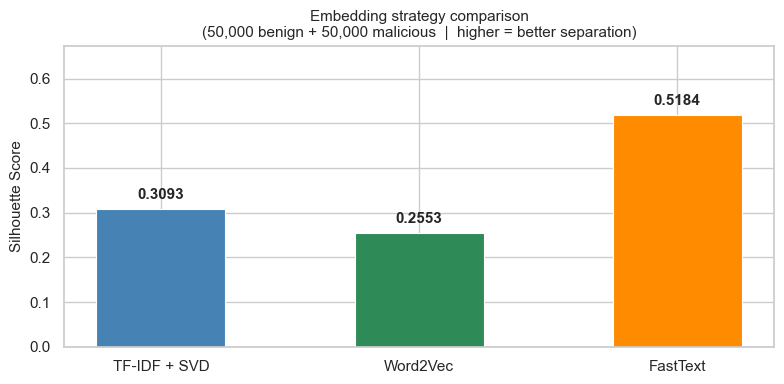


Best strategy: FastText  (silhouette = 0.5184)


In [7]:
# ── Strategy comparison: silhouette score across all three strategies ───────
from sklearn.metrics import silhouette_score

EVAL_N = 50_000   # per class
rng    = np.random.default_rng(42)

def _balanced_eval(Xb, Xm, n):
    bi = rng.choice(len(Xb), n, replace=len(Xb) < n)
    mi = rng.choice(len(Xm), n, replace=len(Xm) < n)
    X  = np.vstack([Xb[bi], Xm[mi]])
    y  = np.array([0] * n + [1] * n)
    return X, y

print(f'Computing silhouette scores on {EVAL_N:,} benign + {EVAL_N:,} malicious events...')
print(f'(silhouette sample_size=10,000 to limit O(n²) cost)\n')

silhouette_results = {}
for name, Xb, Xm in [
    ('TF-IDF + SVD', X_b,     X_m),
    ('Word2Vec',     X_b_w2v, X_m_w2v),
    ('FastText',     X_b_ft,  X_m_ft),
]:
    X_eval, y_eval = _balanced_eval(Xb, Xm, EVAL_N)
    score = silhouette_score(X_eval, y_eval, sample_size=10_000, random_state=42)
    silhouette_results[name] = round(float(score), 4)
    print(f'  {name:<18}  silhouette = {score:.4f}  |  feature dim = {Xb.shape[1]}')

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue', 'seagreen', 'darkorange']
bars   = ax.bar(list(silhouette_results.keys()), list(silhouette_results.values()),
                color=colors, width=0.5, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=5, fontsize=11, fontweight='bold')
ax.set_ylim(0, min(1.0, max(silhouette_results.values()) * 1.3))
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_title('Embedding strategy comparison\n'
             f'({EVAL_N:,} benign + {EVAL_N:,} malicious  |  higher = better separation)',
             fontsize=11)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.tick_params(axis='x', labelsize=11)
plt.tight_layout()
plt.show()

best = max(silhouette_results, key=silhouette_results.get)
print(f'\nBest strategy: {best}  (silhouette = {silhouette_results[best]:.4f})')

#### 3.5.4 Checkpoint

Saves all Strategy B artefacts to `checkpoints/`: feature matrices (`X_b_w2v`, `X_m_w2v`, `X_b_ft`, `X_m_ft`), trained gensim models, fitted scalers, and an updated `meta.json` with all three strategies' best params and silhouette scores.

In [ ]:
import joblib, json
from pathlib import Path

CKPT_DIR = Path('checkpoints')

# ── Matrices already on disk from build cell — verify only ───────────────────
print('Strategy B matrices (on disk):')
_matrix_paths = {
    'X_b_w2v': CKPT_DIR / 'word2vec' / 'X_b_w2v.npy',
    'X_m_w2v': CKPT_DIR / 'word2vec' / 'X_m_w2v.npy',
    'X_b_ft':  CKPT_DIR / 'fasttext' / 'X_b_ft.npy',
    'X_m_ft':  CKPT_DIR / 'fasttext' / 'X_m_ft.npy',
}
for name, p in _matrix_paths.items():
    _mm = np.load(p, mmap_mode='r')
    print(f'  {name:<12}  {_mm.shape}  {p.stat().st_size / 1e9:.2f} GB')
    del _mm

# ── Gensim models ────────────────────────────────────────────────────────────
print('\nSaving gensim models...')
for col in TEXT_COLS:
    w2v_models[col].save(str(CKPT_DIR / 'word2vec' / f'w2v_{col}.model'))
    ft_models[col].save(str(CKPT_DIR / 'fasttext'  / f'ft_{col}.model'))

# ── Scalers ──────────────────────────────────────────────────────────────────
print('Saving scalers...')
joblib.dump(final_scaler_w2v, CKPT_DIR / 'word2vec' / 'final_scaler_w2v.joblib')
joblib.dump(final_scaler_ft,  CKPT_DIR / 'fasttext'  / 'final_scaler_ft.joblib')

# ── Update meta.json ─────────────────────────────────────────────────────────
_meta = json.loads((CKPT_DIR / 'meta.json').read_text())
_meta['strategy_b'] = {
    'w2v_best':    _w2v_best,
    'ft_best':     _ft_best,
    'feature_dim': {'w2v': int(X_b_w2v.shape[1]), 'ft': int(X_b_ft.shape[1])},
    'silhouette':  silhouette_results,
}
(CKPT_DIR / 'meta.json').write_text(json.dumps(_meta, indent=2))

total_gb = sum(p.stat().st_size for p in _matrix_paths.values()) / 1e9
print(f'\nSaved to: {CKPT_DIR.resolve()}')
print(f'Matrix storage : {total_gb:.2f} GB')
print(f'Silhouette     : {silhouette_results}')


## 4. Model Approaches

With the feature matrix validated, three model stages are trained:

### 4.1 Anomaly Detection — Event-level

Trained on **benign-only** LMD data. At inference, anomaly score = deviation from the benign distribution.

| Model | Approach | Notes |
|---|---|---|
| **Isolation Forest** | Random partitioning; short average path length = anomaly | Fast, interpretable, no GPU required |
| **Autoencoder** | Reconstruction error on benign events; high error = anomaly | Semi-supervised; captures non-linear structure |

### 4.2 Anomaly Detection — Sequence-level

Trained on **session-windowed** (grouped by `process_guid`) benign sequences. Anomaly score = next-event reconstruction error.

| Model | Notes |
|---|---|
| **GRU autoencoder** | Lightweight, fast convergence |
| **Transformer autoencoder** | Captures long-range dependencies within a process session |

Key difference from the previous design: windows are built with `build_session_windows()` — events are windowed **within** individual process sessions, not across dataset boundaries.

### 4.3 Technique Attribution — Supervised Classifier

Trained on **OTRF Atomic + Splunk techniques** (ground-truth T-codes). Given a flagged event or window, predicts the most likely ATT&CK technique.

| Model | Notes |
|---|---|
| **LightGBM / XGBoost** | Strong baseline for tabular features; fast; handles class imbalance |
| **MLP classifier** | Same feature matrix; can share a backbone with the autoencoder encoder |

Replaces the rule-based `attck_mapper.py` entirely.